<p><font size="6" color='grey'> <b>
Machine Learning
</b></font> </br></p>
<p><font size="5" color='grey'> <b>
Supervised Learning - Decision Tree Classifier - Cancer
</b></font> </br></p>

---


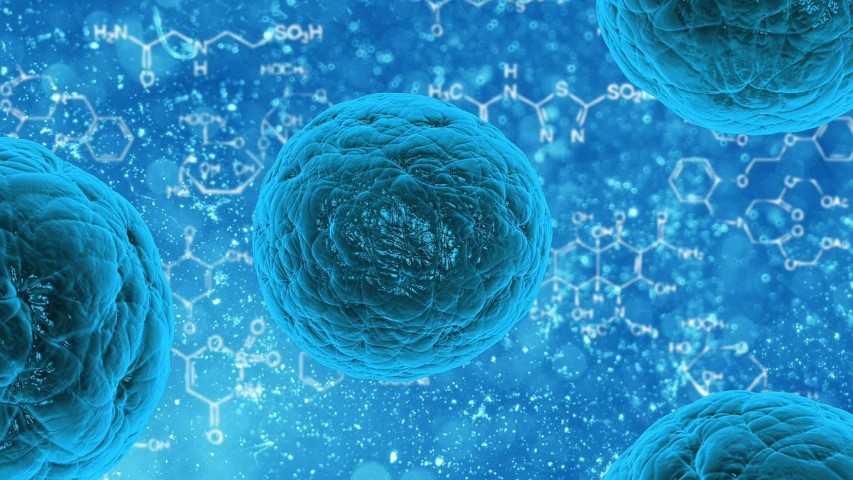

Bild von <a href="https://pixabay.com/de/users/publicdomainpictures-14/?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">PublicDomainPictures</a> auf <a href="https://pixabay.com/de//?utm_source=link-attribution&utm_medium=referral&utm_campaign=image&utm_content=163711">Pixabay</a>

# **0  <font color='orange'>|</font> Install & Import**
***

In [ ]:
# Install
!pip install -q ucimlrepo
!pip install -q dtreeviz

In [ ]:
# Import
import pandas as pd
from ucimlrepo import fetch_ucirepo

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn import tree
from sklearn.tree import export_text

import plotly.express as px
import plotly.subplots as sp

import graphviz
import dtreeviz

In [ ]:
# Warnung ausstellen
import warnings
warnings.filterwarnings('ignore')

# 1 | Understand
---


<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Aufgabe verstehen</br>
✅ Daten sammeln</br>
✅ Statistische Analyse (Min, Max, Mean, Korrelation, ...)</br>
✅ Datenvisualisierung (Streudiagramm, Box-Plot, ...)</br>
✅ Prepare Schritte festlegen</br>

<p><font color='black' size="5">
📒 Anwendungsfall
</font></p>




**Beschreibung:**   
Diese Arbeit entstand aus dem Wunsch, Gewebeproben ausschließlich auf der Grundlage einer Feinnadelpunktion (FNA) genau zu diagnostizieren. In Zusammenarbeit mit Prof. Mangasarian und zwei seiner Doktoranden, Rudy Setiono und Kristin Bennett , wurde mithilfe der Multisurface-Methode (MSM) zur Mustertrennung dieser neun Merkmale ein Klassifikator erstellt, der 97 % der neuen Fälle erfolgreich diagnostizierte. Der resultierende Datensatz ist als Wisconsin Breast Cancer Data bekannt.


Die Arbeit an der Bildanalyse begann 1990 mit der Aufnahme von Nick Street in das Forschungsteam. Ziel war es, die Probe anhand eines digitalen Bildes eines kleinen Abschnitts des FNA-Objektträgers zu diagnostizieren.

**Diagnoseablauf:**

Es wird aus dem Gewebe eine FNA entnommen. Dieses Material wird dann auf einen Objektträger montiert und gefärbt, um die Zellkerne hervorzuheben. Ein Teil des Objektträgers, in dem die Zellen gut differenziert sind, wird dann mit einer Digitalkamera und einem Framegrabber-Board gescannt.
Anschließend isoliert der Anwender die einzelnen Zellkerne . Mit einem Mauszeiger zeichnet der Benutzer die ungefähre Grenze jedes Kerns. Mithilfe eines Computer-Vision-Ansatzes, konvergieren diese Annäherungen dann an die genauen nuklearen Grenzen. Sobald alle (oder die meisten) Kerne auf diese Weise isoliert wurden, berechnet das Programm Werte für jedes der zehn Merkmale jedes Kerns und misst Größe, Form und Textur. Der Mittelwert, der Standardfehler und die Extremwerte dieser Merkmale werden berechnet, was zu insgesamt 30 Kernmerkmalen für jede Probe führt.

[DataSet](https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original)

[Info](https://pages.cs.wisc.edu/~olvi/uwmp/cancer.html)

**Features:**


+ Dicke: 1 - 10
+ Einheitlichkeit der Zellgröße: 1 - 10
+ Gleichmäßigkeit der Zellform: 1 - 10
+ Randhaftung: 1 - 10
+ Größe einzelner Epithelzellen: 1 - 10
+ Nackte Kerne: 1 - 10
+ Blandes Chromatin: 1 - 1
+ Normale Nukleolen: 1 - 10
+ Mitosen: 1 - 10

**Klassen:**

+ Klasse: (2 für gutartig, 4 für bösartig)

In [ ]:
# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
data = breast_cancer_wisconsin_original.data.features
target = breast_cancer_wisconsin_original.data.targets

# **2 <font color='orange'>|</font> Prepare**

---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Nicht benötigte Features löschen</br>
✅ Datentyp ermitteln/ändern</br>
✅ Duplikate ermitteln/löschen</br>
✅ Missing Values behandeln</br>
✅ Ausreißer behandeln</br>
✅ Kategorischer Features codieren</br>
✅ Numerischer Features skalieren</br>
✅ Feature-Engineering (neue Features schaffen)</br>
✅ Dimensionalität reduzieren</br>
✅ Resampling (Over-/Undersampling)</br>
✅ Pipeline erstellen/konfigurieren</br>
✅ Train-Test-Split durchführen</br>

<p><font color='black' size="5">
Missing Values
</font></p>

In [ ]:
data = data.dropna()

In [ ]:
target = target.loc[data.index]

Anpassung Ausprägung 0/1

In [ ]:
target.replace([2,4], [0,1], inplace=True)

<p><font color='black' size="5">
Train-Test-Split
</font></p>

In [ ]:
data_train, data_test, target_train, target_test = train_test_split(data, target, test_size=0.20, random_state=42, stratify=target)
data_train.shape, data_test.shape, target_train.shape, target_test.shape

((546, 9), (137, 9), (546, 1), (137, 1))

# **3 <font color='orange'>|</font> Modeling**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellauswahl treffen</br>
✅ Pipeline erweitern/konfigurieren</br>
✅ Training durchführen</br>
✅ Hyperparameter Tuning</br>
✅ Cross-Valdiation</br>
✅ Bootstrapping</br>
✅ Regularization</br>

<p><font color='black' size="5">
Modellauswahl und Training
</font></p>

In [ ]:
model = DecisionTreeClassifier(max_depth=3, random_state=42)

In [ ]:
model.fit(data_train, target_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

# **4 <font color='orange'>|</font> Evaluate**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Prognose (Train, Test) erstellen</br>
✅ Modellgüte prüfen</br>
✅ Residuenanalyse erstellen</br>
✅ Feature Importance/Selektion prüfen</br>
✅ Robustheitstest erstellen</br>
✅ Modellinterpretation erstellen</br>
✅ Sensitivitätsanalyse erstellen</br>
✅ Kommunikation (Key Takeaways)</br>

<p><font color='black' size="5">
Prognose
</font></p>

In [ ]:
target_train_pred = model.predict(data_train)
target_test_pred = model.predict(data_test)

<p><font color='black' size="5">
Accuracy
</font></p>

In [ ]:
acc_train = accuracy_score(target_train, target_train_pred) * 100
print (f"Modell: {model} -- Train -- Accuracy: {acc_train:5.2f}")

Modell: DecisionTreeClassifier(max_depth=3, random_state=42) -- Train -- Accuracy: 96.52


In [ ]:
acc_test = accuracy_score(target_test, target_test_pred) * 100
print (f'Modell: {model} -- Test -- Accuracy: {acc_test:5.2f}%')

Modell: DecisionTreeClassifier(max_depth=3, random_state=42) -- Test -- Accuracy: 95.62%


<p><font color='black' size="5">
Confusion Matrix
</font></p>

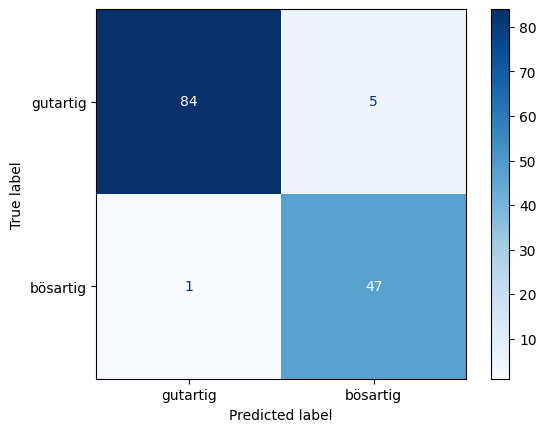

In [ ]:
conf_matrix = confusion_matrix(target_test, target_test_pred)
display_labels_= ['gutartig','bösartig']
disp = ConfusionMatrixDisplay(conf_matrix, display_labels=display_labels_)
disp.plot(cmap='Blues')

In [ ]:
print(classification_report(target_test, target_test_pred, target_names=display_labels_))

              precision    recall  f1-score   support

    gutartig       0.99      0.94      0.97        89
    bösartig       0.90      0.98      0.94        48

    accuracy                           0.96       137
   macro avg       0.95      0.96      0.95       137
weighted avg       0.96      0.96      0.96       137



<p><font color='black' size="5">
Aufbau Analysewürfel
</font></p>

In [ ]:
# Übernahme der Testdaten
cube = data_test.copy()
cube.reset_index(inplace=True)

# Übernahme Target real & predict
cube['real'] = pd.DataFrame(target_test.values, columns=['real'])
cube['predict'] = pd.DataFrame(target_test_pred, columns=['predict'])

<p><font color='black' size="5">
Visualisierung
</font></p>

In [ ]:
# Histogramm
title_ = 'Histogramm real vs predict'
fig = px.histogram(cube, x=['real', 'predict'], nbins=2, title=title_)
fig.update_layout(barmode='group',bargap=0.1, width=600, height=600)
fig.show()

In [ ]:
# real <> predict
cube[cube.real != cube.predict].describe().T

,count,mean,std,min,25%,50%,75%,max
index,6.0,265.666667,234.499183,1.0,72.00,274.0,399.50,599.0
Clump_thickness,6.0,5.333333,0.516398,5.0,5.00,5.0,5.75,6.0
Uniformity_of_cell_size,6.0,4.000000,2.529822,2.0,3.00,3.0,3.75,9.0
Uniformity_of_cell_shape,6.0,4.166667,1.471960,3.0,3.25,4.0,4.00,7.0
Marginal_adhesion,6.0,3.666667,1.632993,1.0,3.00,4.0,5.00,5.0
Single_epithelial_cell_size,6.0,3.666667,2.160247,1.0,2.25,3.5,4.75,7.0
Bare_nuclei,6.0,6.166667,3.763863,1.0,3.50,6.5,9.50,10.0
Bland_chromatin,6.0,3.166667,1.169045,1.0,3.00,3.5,4.00,4.0
Normal_nucleoli,6.0,3.500000,2.258318,1.0,2.00,3.0,4.75,7.0
Mitoses,6.0,1.333333,0.816497,1.0,1.00,1.0,1.00,3.0


In [ ]:
cube[cube.real != cube.predict]

,index,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,real,predict
30,599,5,2,4,1,1,1.0,1,1,1,0,1
41,252,6,3,3,5,3,10.0,3,5,3,0,1
46,296,5,3,4,3,4,5.0,4,7,1,0,1
79,1,5,4,4,5,7,10.0,3,2,1,0,1
106,434,6,9,7,5,5,8.0,4,2,1,0,1
115,12,5,3,3,3,2,3.0,4,4,1,1,0


<p><font color='black' size="5">
❗Feature Importance
</font></p>

In [ ]:
title_ = 'Feature Importance Cancer'
px.bar(x=model.feature_importances_, y=data.columns, title = title_, width=800, height=600).update_yaxes(categoryorder="total ascending")

<p><font color='black' size="5">
🌳 Darstellen des Entscheidungsbaums
</font></p>

Erstellen einen Textbericht, der die Regeln eines Entscheidungsbaums zeiget.
Für die Anzeige class_name muss ein Update auf sklearn 1.4 erfolgen.

In [ ]:
# tree_rules = export_text(model, feature_names=list(model.feature_names_in_), class_names=display_labels_, spacing=7, decimals=1,  show_weights=True)
tree_rules = export_text(model, feature_names=list(model.feature_names_in_), spacing=7, decimals=1,  show_weights=True)
print(tree_rules)

|------- Uniformity_of_cell_shape <= 3.5
|       |------- Bare_nuclei <= 5.5
|       |       |------- Uniformity_of_cell_size <= 3.5
|       |       |       |------- weights: [339.0, 6.0] class: 0
|       |       |------- Uniformity_of_cell_size >  3.5
|       |       |       |------- weights: [1.0, 3.0] class: 1
|       |------- Bare_nuclei >  5.5
|       |       |------- Clump_thickness <= 1.5
|       |       |       |------- weights: [1.0, 1.0] class: 0
|       |       |------- Clump_thickness >  1.5
|       |       |       |------- weights: [0.0, 13.0] class: 1
|------- Uniformity_of_cell_shape >  3.5
|       |------- Uniformity_of_cell_size <= 1.5
|       |       |------- weights: [3.0, 0.0] class: 0
|       |------- Uniformity_of_cell_size >  1.5
|       |       |------- Uniformity_of_cell_size <= 4.5
|       |       |       |------- weights: [9.0, 35.0] class: 1
|       |       |------- Uniformity_of_cell_size >  4.5
|       |       |       |------- weights: [2.0, 133.0] class: 

Als Grafik mit graphviz

In [ ]:
# DOT data
dot_data = tree.export_graphviz(model, out_file=None,
                                feature_names=data.columns,
                                class_names=display_labels_,
                                filled=True)



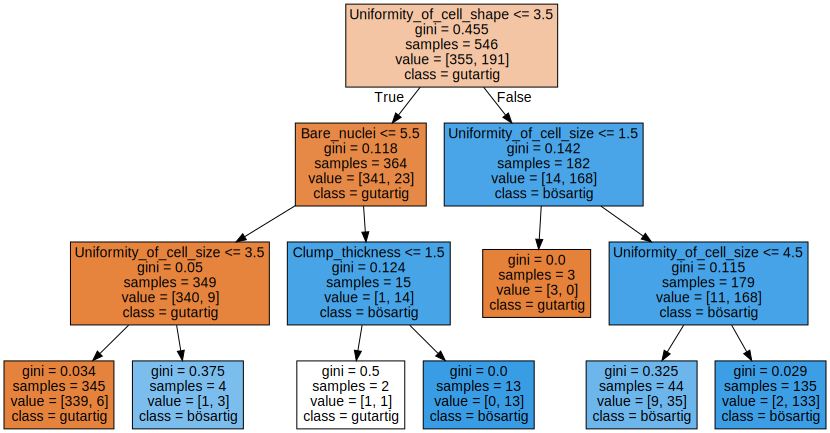

In [ ]:
# Draw graph
graph = graphviz.Source(dot_data, format="png")
graph

Als Grafik mit dtreeviz

In [129]:
viz_model = dtreeviz.model(model, data, target['Class'], target_name="target", class_names=display_labels_, feature_names=data.columns)

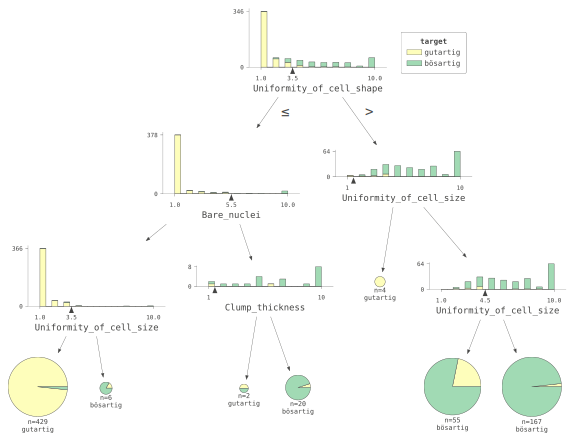

In [130]:
viz_model.view(scale=1.0, fontname='Monospace')

In [ ]:
viz_model.view(scale=1.2, orientation="LR", fontname='Monospace')

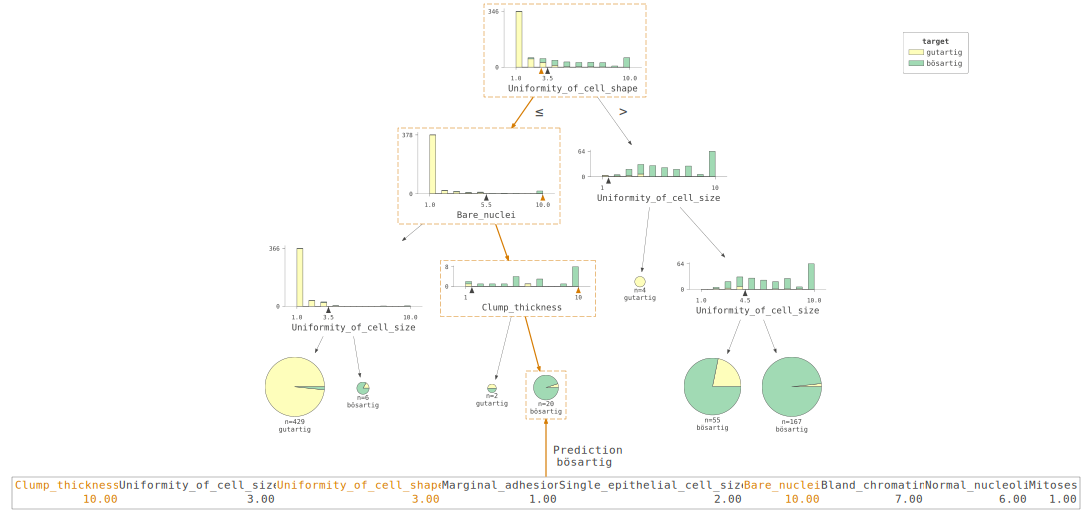

In [131]:
# local Explanation
one = data_test.iloc[13]
viz_model.view(x=one, fontname='Monospace')

In [ ]:
# local Explanation
viz_model.view(x=one, show_just_path=True, fontname='Monospace')

In [ ]:
tree_img = viz_model.view(scale=0.8, fontname='Monospace')
tree_img.save('tree.svg')

# **5 <font color='orange'>|</font> Deploy**
---

<p><font color='black' size="5">📋 Checkliste</font></p>

✅ Modellexport und -speicherung</br>
✅ Abhängigkeiten und Umgebung</br>
✅ Sicherheit und Datenschutz</br>
✅ In die Produktion integrieren</br>
✅ Tests und Validierung</br>
✅ Dokumentation & Wartung</br>